In [ ]:
# import pandas as pd

# # Load CSVs
# temporal_path = "/home/ahallur1/spear/Seamless_Experiments/Temporal/seamless_temporal_features.csv"
# f0_path = "/home/ahallur1/spear/Seamless_Experiments/F0/seamless_f0_features.csv"

# lex_df = pd.read_csv(temporal_path)
# f0_df = pd.read_csv(f0_path, usecols=["orig_id", "wav_path"])

# wav_path_map = dict(zip(f0_df["orig_id"], f0_df["wav_path"]))

# lex_df["wav_path"] = lex_df["orig_id"].map(wav_path_map)

# missing = lex_df["wav_path"].isna().sum()
# print(f"Rows with missing wav_path after fix: {missing}")

# # Save fixed file
# lex_df.to_csv("/home/ahallur1/spear/Seamless_Experiments/Temporal/seamless_temporal_features_fixed.csv", index=False)


Rows with missing wav_path after fix: 0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

sns.set(style="whitegrid", context="talk")
DATA_PATH = Path("/home/ahallur1/spear/Seamless_Experiments/Lexical/seamless_lexical_features.csv")
MIN_WORDS_FOR_LD = 50
HIGH_CONF_THRESH = 0.7

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)


df["length_bin"] = pd.cut(
    df["total_words"],
    bins=[0, 50, 100, 300, 1000, np.inf],
    labels=["<50", "50–100", "100–300", "300–1000", ">1000"],
    )

(129215, 20)


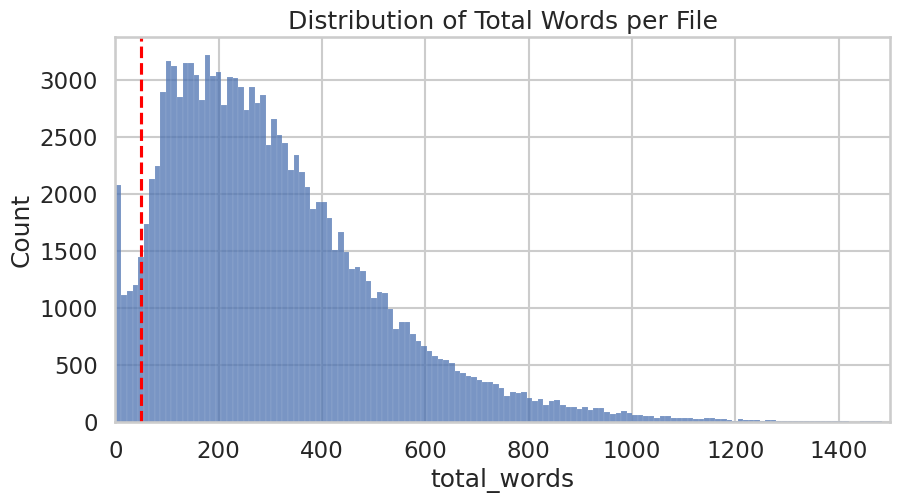

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df["total_words"], bins=800)
plt.axvline(MIN_WORDS_FOR_LD, color="red", linestyle="--")
plt.xlim(0, 1500)
plt.title("Distribution of Total Words per File")
plt.show()

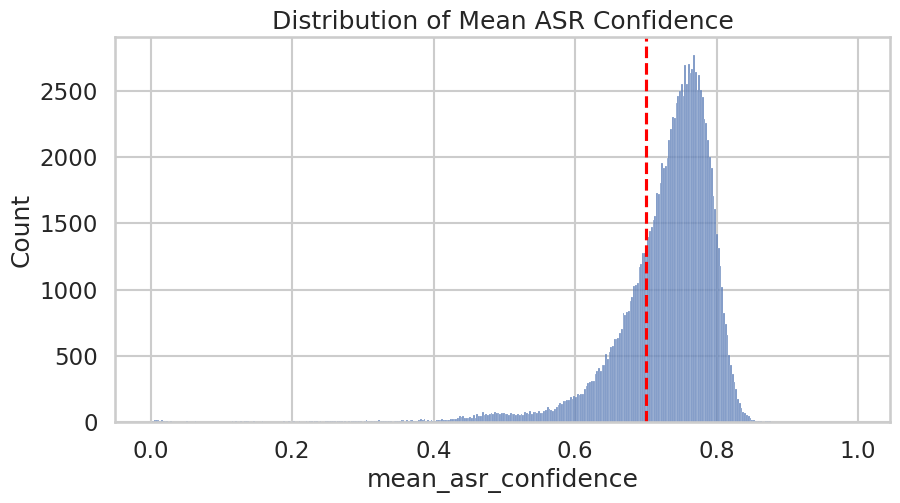

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df["mean_asr_confidence"], bins=400)
plt.axvline(HIGH_CONF_THRESH, color="red", linestyle="--")
plt.title("Distribution of Mean ASR Confidence")
plt.show()

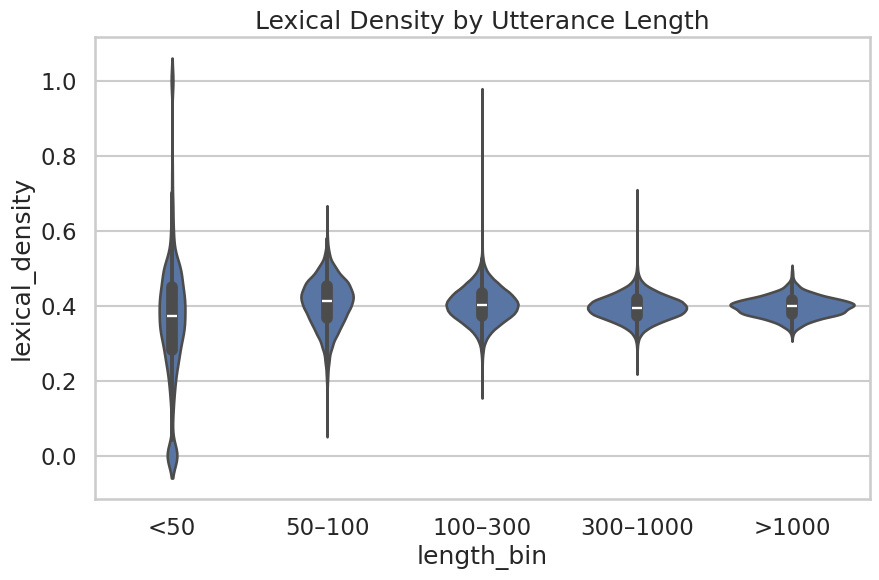

In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="length_bin", y="lexical_density", data=df)
plt.title("Lexical Density by Utterance Length")
plt.show()

In [6]:
df["sufficient_length"] = df["total_words"] >= MIN_WORDS_FOR_LD
df["high_confidence"] = df["mean_asr_confidence"] >= HIGH_CONF_THRESH

print("Total files:", len(df))
print("Files with >= 50 words:", df["sufficient_length"].sum())
print("High-confidence files:", df["high_confidence"].sum())

Total files: 129215
Files with >= 50 words: 119927
High-confidence files: 95356


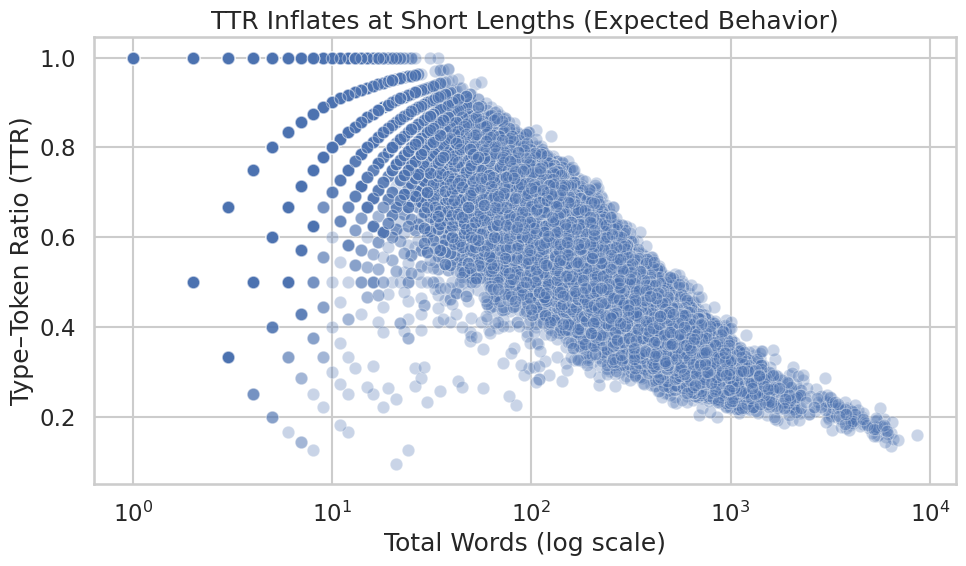

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="total_words",
    y="ttr",
    alpha=0.3
)
plt.xscale("log")
plt.xlabel("Total Words (log scale)")
plt.ylabel("Type–Token Ratio (TTR)")
plt.title("TTR Inflates at Short Lengths (Expected Behavior)")
plt.tight_layout()
plt.show()


In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(
    df_ld["mattr_small"],
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6,
    label="MATTR Small Window"
)
sns.histplot(
    df_ld["mattr_large"],
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6,
    label="MATTR Large Window"
)

plt.xlabel("MATTR Value")
plt.ylabel("Density")
plt.title("Distribution of MATTR (Small vs Large Window)")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'df_ld' is not defined

<Figure size 900x500 with 0 Axes>

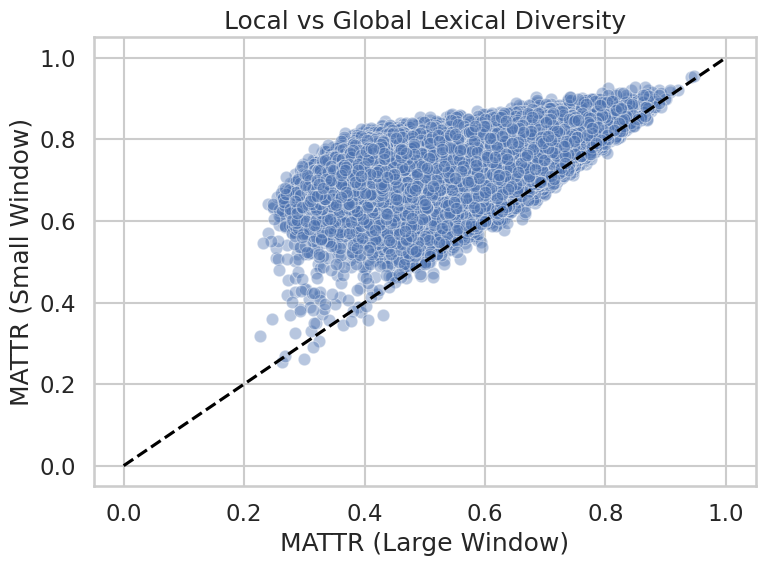

In [ ]:
df_ld = df[df["sufficient_length"]].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_ld,
    x="mattr_large",
    y="mattr_small",
    alpha=0.4
)
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("MATTR (Large Window)")
plt.ylabel("MATTR (Small Window)")
plt.title("Local vs Global Lexical Diversity")
plt.tight_layout()
plt.show()

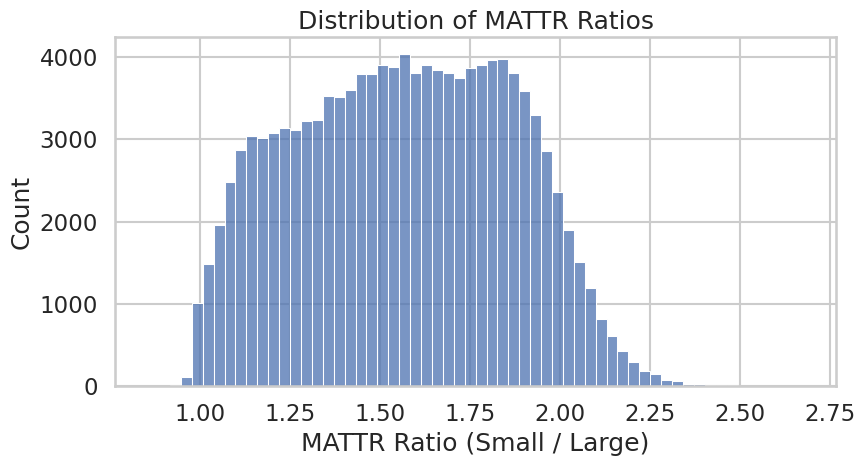

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df_ld["mattr_ratio"], bins=60)
plt.xlabel("MATTR Ratio (Small / Large)")
plt.title("Distribution of MATTR Ratios")
plt.tight_layout()
plt.show()

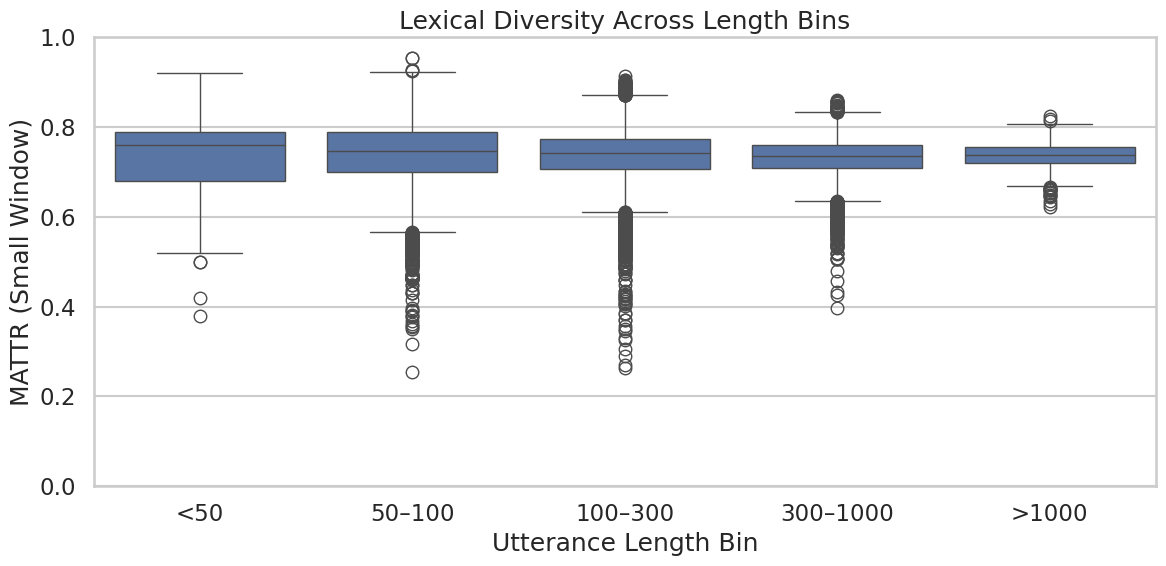

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_ld,
    x="length_bin",
    y="mattr_small"
)
plt.xlabel("Utterance Length Bin")
plt.ylabel("MATTR (Small Window)")
plt.ylim(0, 1)
plt.title("Lexical Diversity Across Length Bins")
plt.tight_layout()
plt.show()

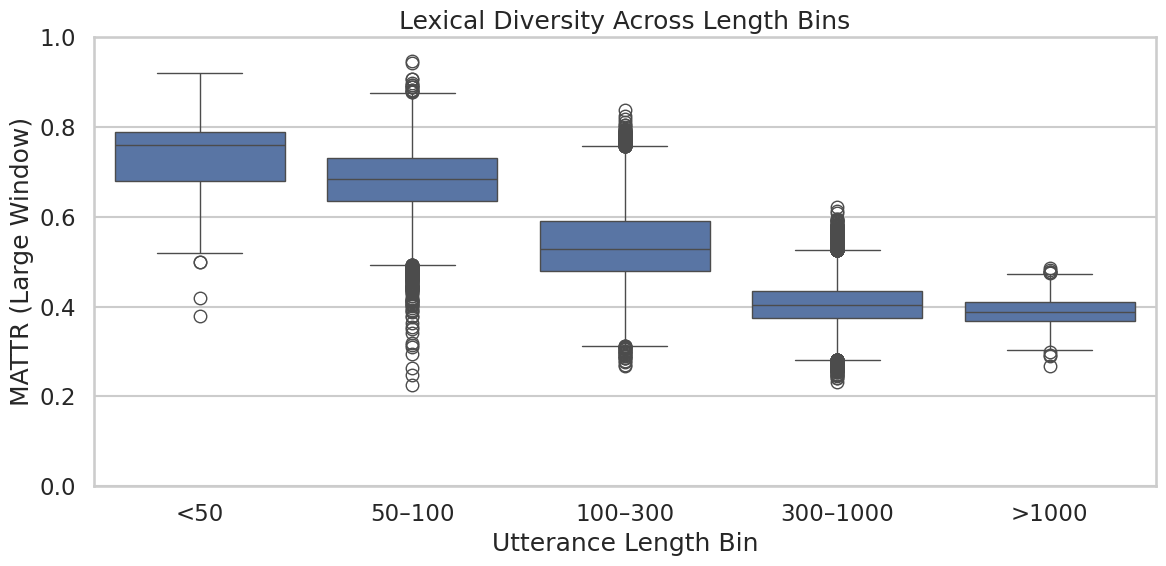

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_ld,
    x="length_bin",
    y="mattr_large"
)
plt.xlabel("Utterance Length Bin")
plt.ylabel("MATTR (Large Window)")
plt.ylim(0, 1)
plt.title("Lexical Diversity Across Length Bins")
plt.tight_layout()
plt.show()

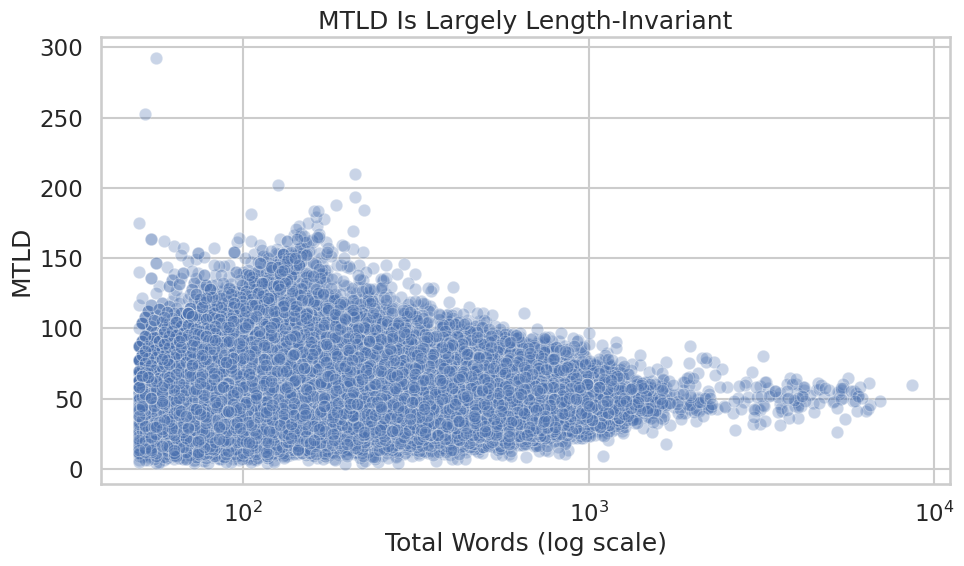

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ld,
    x="total_words",
    y="mtld",
    alpha=0.3
)
plt.xscale("log")
plt.xlabel("Total Words (log scale)")
plt.ylabel("MTLD")
plt.title("MTLD Is Largely Length-Invariant")
plt.tight_layout()
plt.show()

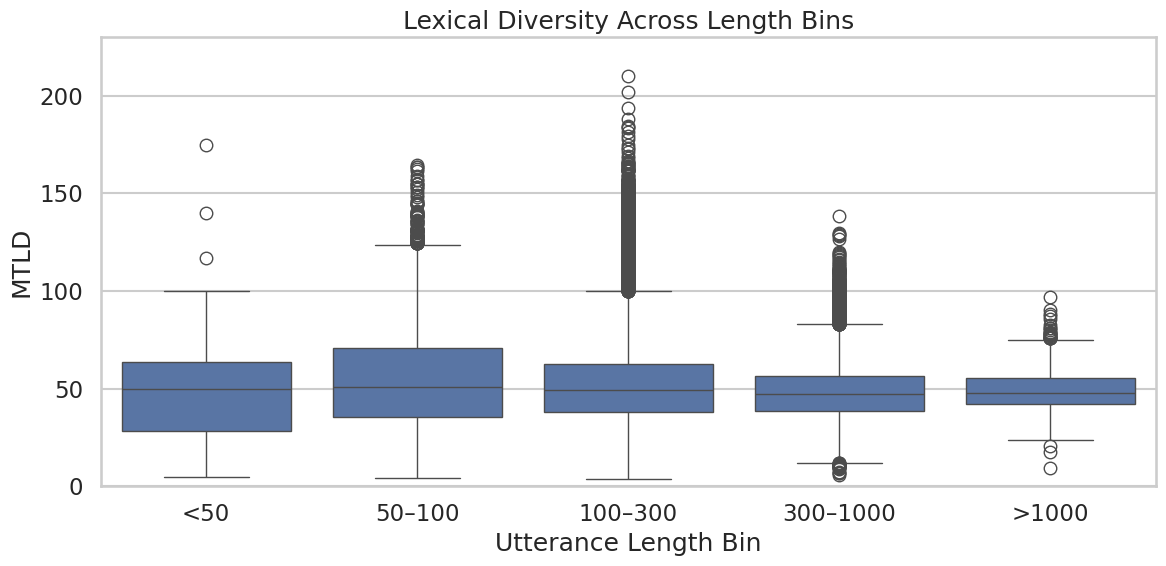

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_ld,
    x="length_bin",
    y="mtld"
)
plt.xlabel("Utterance Length Bin")
plt.ylabel("MTLD")
plt.ylim(0, 230)
plt.title("Lexical Diversity Across Length Bins")
plt.tight_layout()
plt.show()

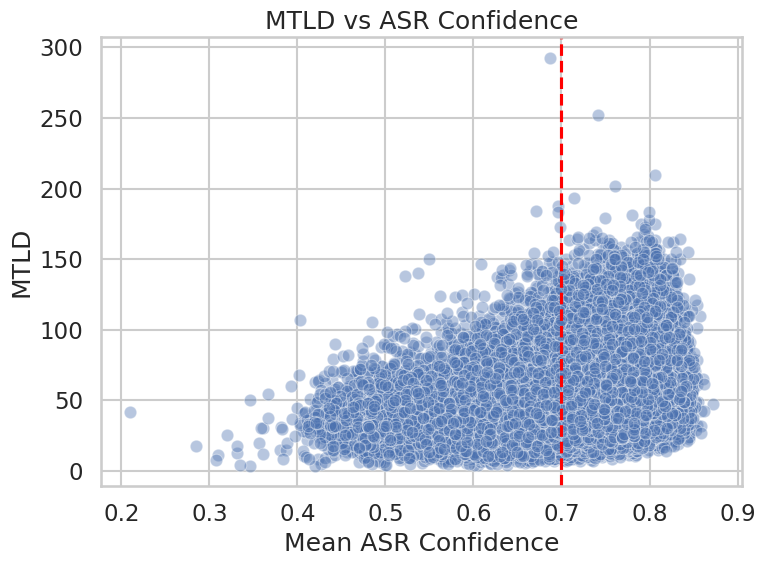

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_ld,
    x="mean_asr_confidence",
    y="mtld",
    alpha=0.4
)
plt.axvline(HIGH_CONF_THRESH, color="red", linestyle="--")
plt.xlabel("Mean ASR Confidence")
plt.ylabel("MTLD")
plt.title("MTLD vs ASR Confidence")
plt.tight_layout()
plt.show()

In [ ]:
metrics = ["ttr", "mattr_small", "mattr_large", "mattr_ratio", "mtld"]

corrs = {}
for m in metrics:
    rho, p = spearmanr(df_ld["total_words"], df_ld[m])
    corrs[m] = (rho, p)

pd.DataFrame(
    corrs, index=["Spearman ρ", "p-value"]
).T


,Spearman ρ,p-value
ttr,-0.906796,0.000000e+00
mattr_small,-0.095010,1.758062e-238
mattr_large,-0.880381,0.000000e+00
mattr_ratio,0.942351,0.000000e+00
mtld,-0.085416,5.474439e-193


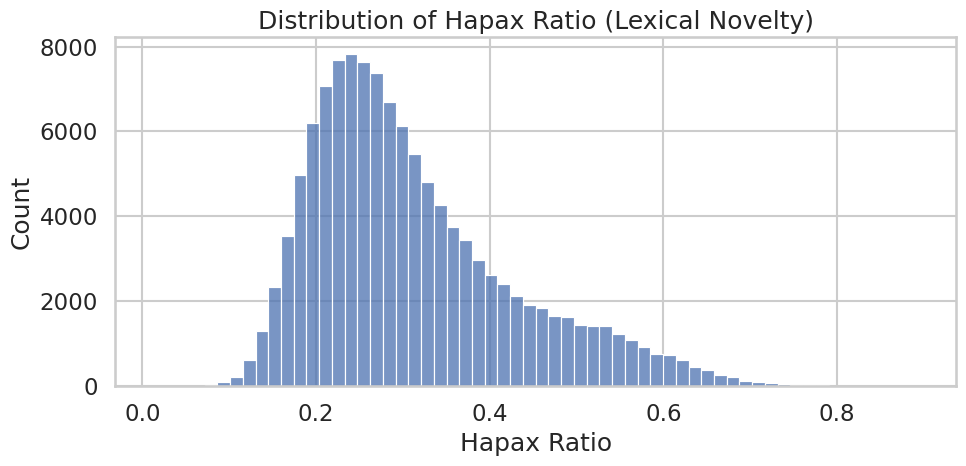

In [ ]:
df_ld = df[df["sufficient_length"]].copy()
plt.figure(figsize=(10, 5))
sns.histplot(df_ld["hapax_ratio"], bins=60)
plt.xlabel("Hapax Ratio")
plt.title("Distribution of Hapax Ratio (Lexical Novelty)")
plt.tight_layout()
plt.show()

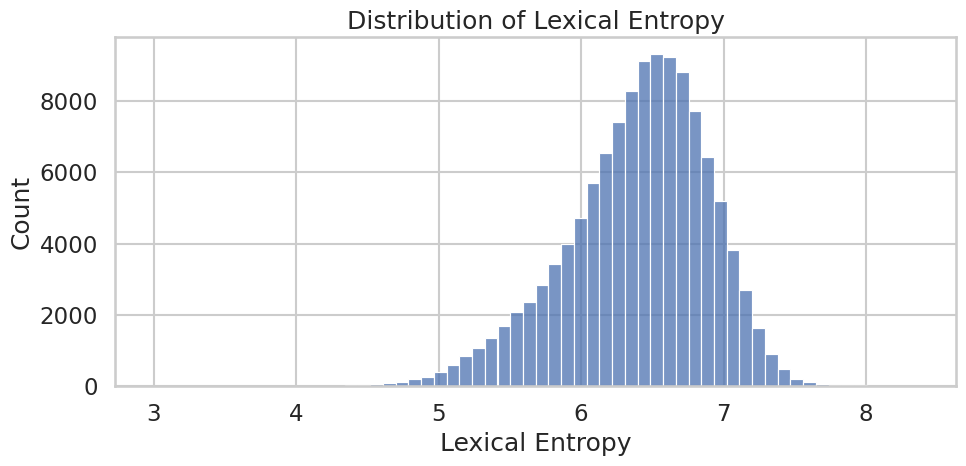

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_ld["lexical_entropy"], bins=60)
plt.xlabel("Lexical Entropy")
plt.title("Distribution of Lexical Entropy")
plt.tight_layout()
plt.show()

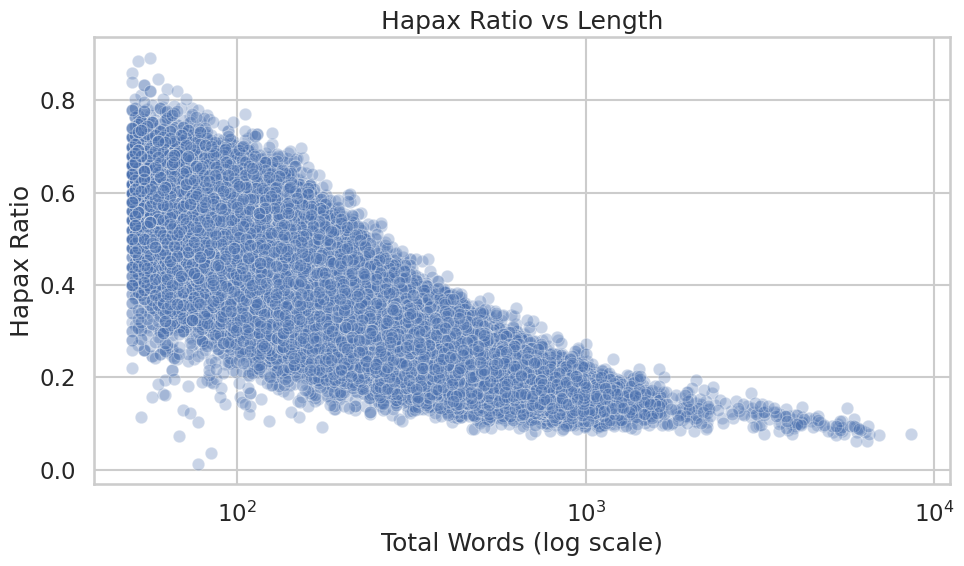

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ld,
    x="total_words",
    y="hapax_ratio",
    alpha=0.3
)
plt.xscale("log")
plt.xlabel("Total Words (log scale)")
plt.ylabel("Hapax Ratio")
plt.title("Hapax Ratio vs Length")
plt.tight_layout()
plt.show()

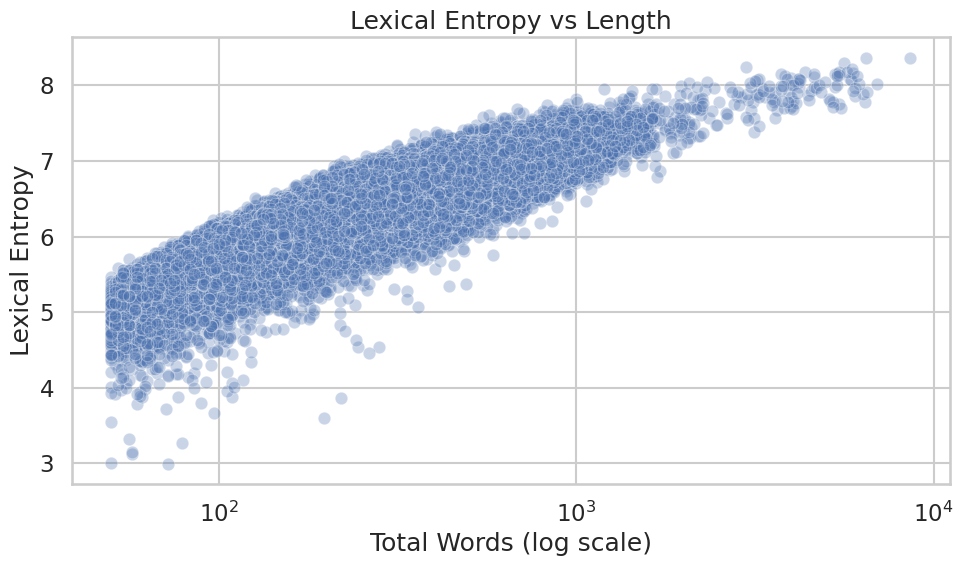

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ld,
    x="total_words",
    y="lexical_entropy",
    alpha=0.3
)
plt.xscale("log")
plt.xlabel("Total Words (log scale)")
plt.ylabel("Lexical Entropy")
plt.title("Lexical Entropy vs Length")
plt.tight_layout()
plt.show()


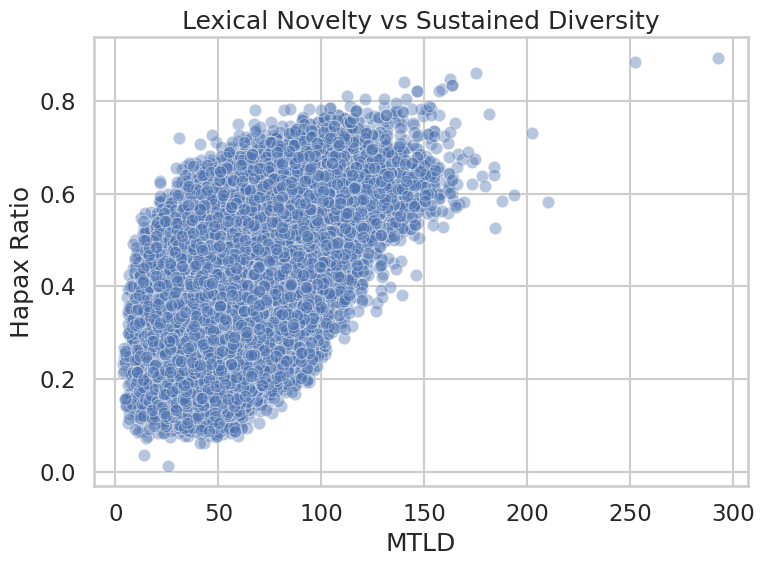

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_ld,
    x="mtld",
    y="hapax_ratio",
    alpha=0.4
)
plt.xlabel("MTLD")
plt.ylabel("Hapax Ratio")
plt.title("Lexical Novelty vs Sustained Diversity")
plt.tight_layout()
plt.show()

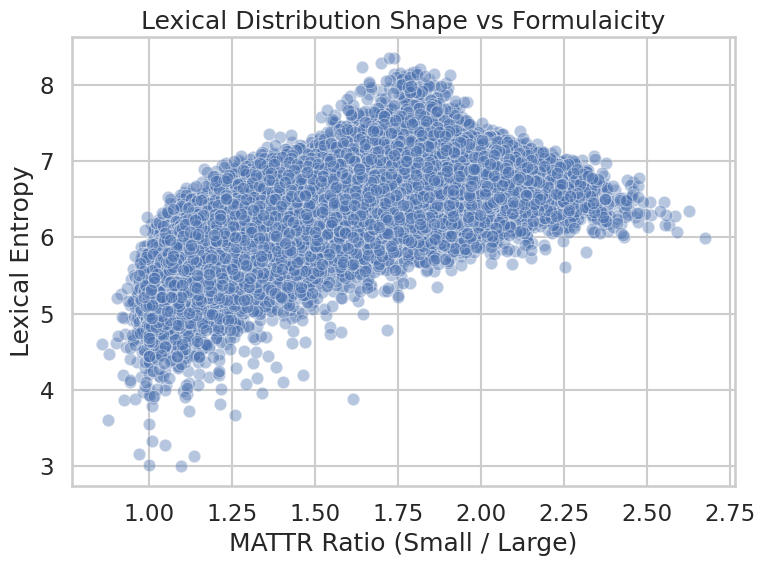

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_ld,
    x="mattr_ratio",
    y="lexical_entropy",
    alpha=0.4
)
plt.xlabel("MATTR Ratio (Small / Large)")
plt.ylabel("Lexical Entropy")
plt.title("Lexical Distribution Shape vs Formulaicity")
plt.tight_layout()
plt.show()

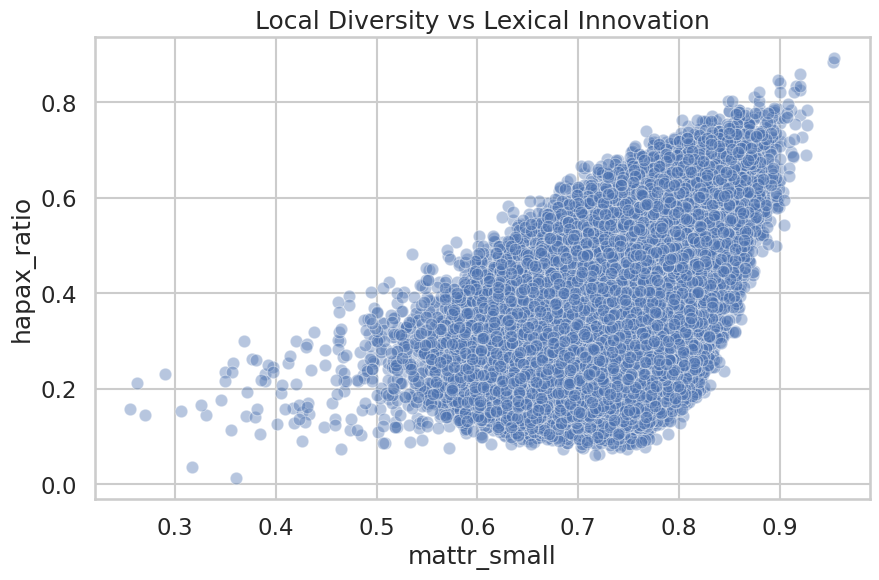

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
data=df,
x="mattr_small",
y="hapax_ratio",
alpha=0.4,
)
plt.title("Local Diversity vs Lexical Innovation")
plt.show()

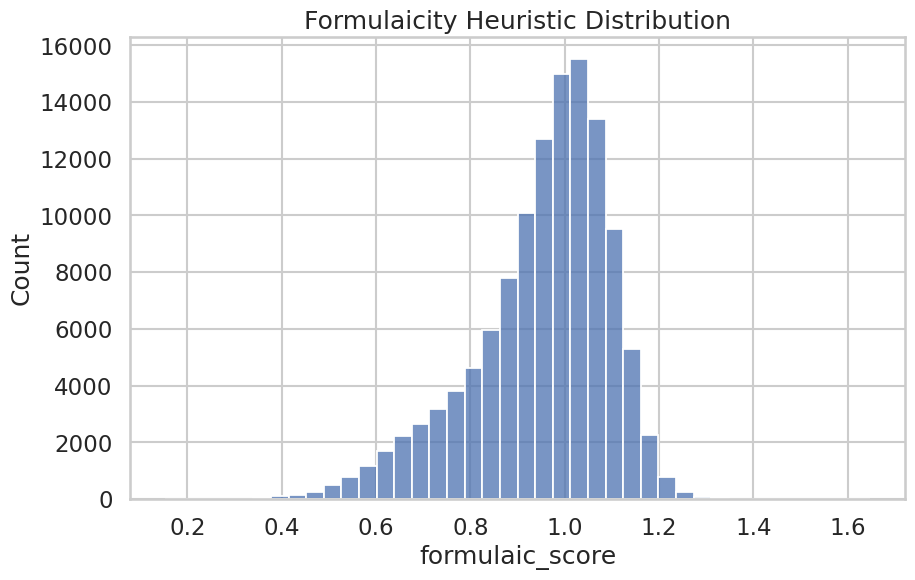

In [ ]:
df["formulaic_score"] = (
(1 - df["mattr_small"]) + (1 - df["hapax_ratio"])
)


plt.figure(figsize=(10, 6))
sns.histplot(df["formulaic_score"], bins=40)
plt.title("Formulaicity Heuristic Distribution")
plt.show()

In [ ]:
df_ld = df[
    (df["total_words"] >= MIN_WORDS_FOR_LD)
].copy()

print(f"Using {len(df_ld)} files for lexical density analysis")


Using 119927 files for lexical density analysis


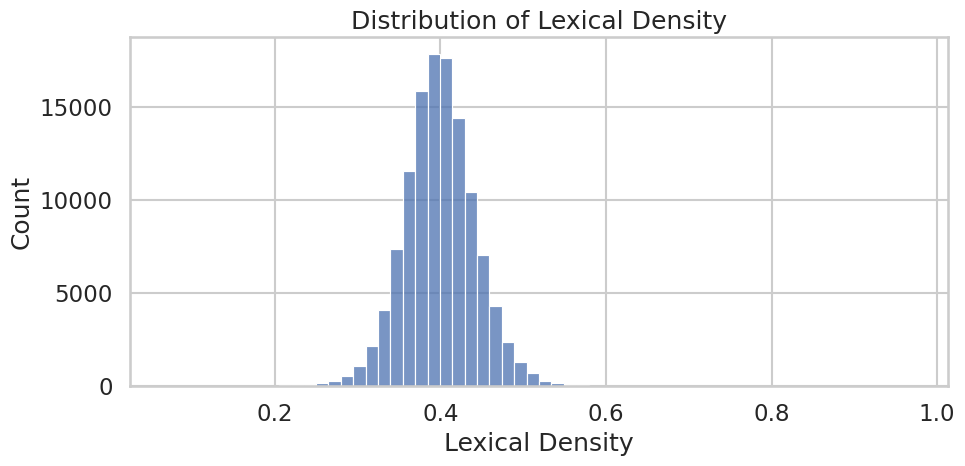

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_ld["lexical_density"], bins=60)
plt.xlabel("Lexical Density")
plt.title("Distribution of Lexical Density")
plt.tight_layout()
plt.show()


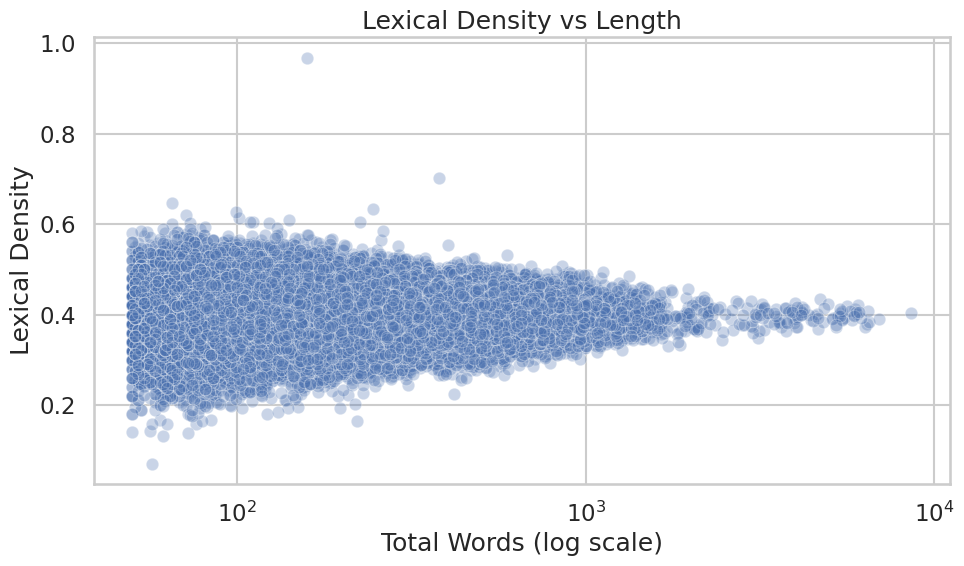

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ld,
    x="total_words",
    y="lexical_density",
    alpha=0.3
)
plt.xscale("log")
plt.xlabel("Total Words (log scale)")
plt.ylabel("Lexical Density")
plt.title("Lexical Density vs Length")
plt.tight_layout()
plt.show()


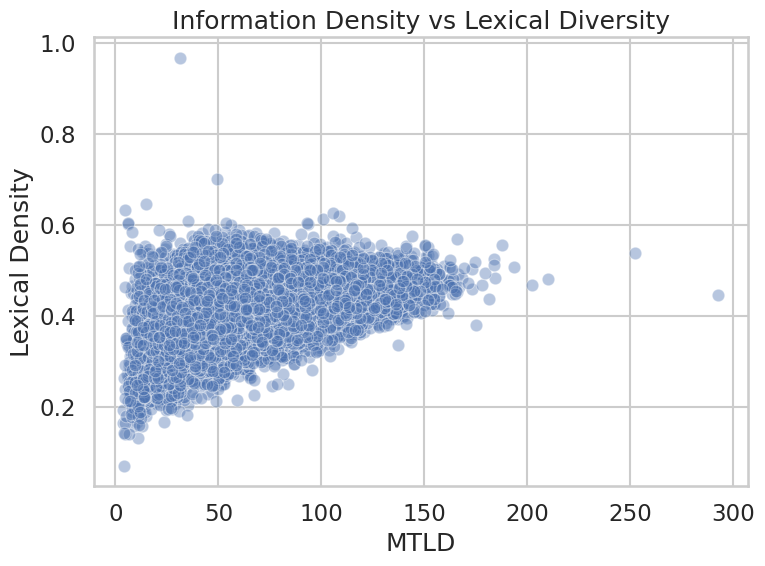

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_ld,
    x="mtld",
    y="lexical_density",
    alpha=0.4
)
plt.xlabel("MTLD")
plt.ylabel("Lexical Density")
plt.title("Information Density vs Lexical Diversity")
plt.tight_layout()
plt.show()


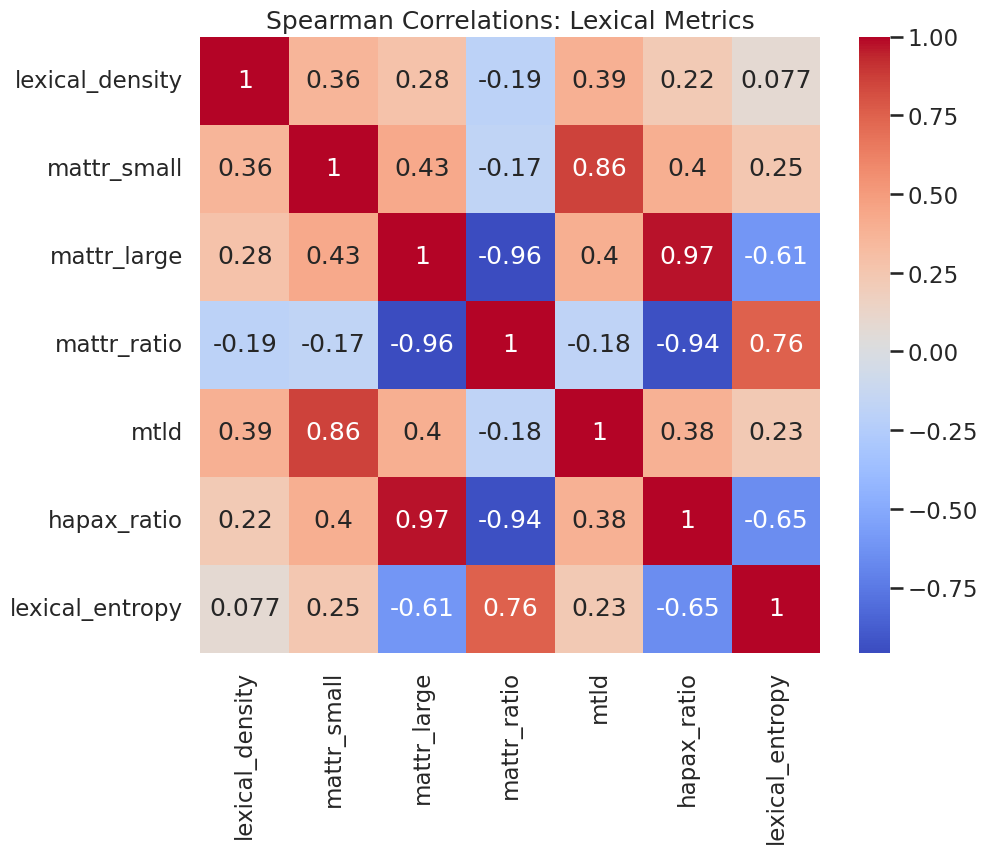

In [ ]:
corr_metrics = [
"lexical_density",
"mattr_small",
"mattr_large",
"mattr_ratio",
"mtld",
"hapax_ratio",
"lexical_entropy",
]


corr = df[corr_metrics].corr(method="spearman")


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Spearman Correlations: Lexical Metrics")
plt.show()